# 01 CNN Baseline — CIFAR-10

このNotebookでは、**CIFAR-10 + CNN の非圧縮baseline**を作る。

Fashion-MNIST版と同じく、学習ループ・評価・保存などの定型処理は完成形に寄せる。  
一方で、CIFAR-10へ移ったことで意味が変わる部分は、自分で考えて埋める。

## 今回の主な違い

Fashion-MNIST:

```text
1 × 28 × 28
```

CIFAR-10:

```text
3 × 32 × 32
```

また、CIFAR-10では学習時だけ軽いdata augmentationを入れる。

## 目標にするCNN

```text
Input: 3 × 32 × 32
    ↓
Conv → ReLU → MaxPool
    ↓
32 × 16 × 16
    ↓
Conv → ReLU → MaxPool
    ↓
64 × 8 × 8
    ↓
Conv → ReLU → MaxPool
    ↓
128 × 4 × 4
    ↓
Global Average Pooling
    ↓
128 × 1 × 1
    ↓
Flatten
    ↓
Linear(? → 256)
ReLU
Dropout
    ↓
Linear(256 → ?)
```

`?` はこのNotebook内で自分で埋める。

## このNotebookで自分で理解する部分

1. CIFAR-10の入力channel数
2. 前段Convの出力channelと次段Convの入力channelの関係
3. Poolingを3回通した後の空間サイズ
4. Flatten後の特徴数
5. 最終層の出力数
6. trainだけaugmentationし、validation/testには入れない理由
7. 後続のSVD実験で、LinearとConvの重みshapeがどう違うか

次Notebookでは、Fashion-MNIST版のように単純に `fc1` だけをSVDするのではなく、  
**層ごとのSVD耐性を見る `02_layer_sensitivity.ipynb`** へ進む想定。


In [1]:
# 標準ライブラリ
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import json
import platform
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ============================================================
# 既存プロジェクトの汎用処理を再利用
# Fashion-MNIST版と同じく、今回の学習テーマではない定型処理は .py 側を使う
# ============================================================
from nn_compression.metrics import count_parameters
from nn_compression.training import evaluate, train_one_epoch
from nn_compression.utils import (
    find_project_root,
    get_experiment_dirs,
    set_seed,
)


## 1. 再現性と実行デバイス

Fashion-MNIST実験と比較しやすくするため、seedは同じ `0` を使う。

ここはCNN / CIFAR-10固有ではないので完成形。


In [2]:
# 再現性のため乱数seedを固定する
SEED = 0
set_seed(SEED)

# CUDA → MPS → CPU の順で利用可能なデバイスを選ぶ
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 2. 保存先

Fashion-MNIST版と同じルールで保存する。

```text
data/
models/30_cifar10/01_cnn_cifar10_baseline/
results/30_cifar10/01_cnn_cifar10_baseline/
```

`Path(".")` へ直接保存せず、プロジェクトルート基準にする。


In [3]:
DATASET_NAME = "30_cifar10"
EXPERIMENT_NAME = "01_cnn_cifar10_baseline"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    DATASET_NAME,
    EXPERIMENT_NAME,
)

checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\30_cifar10\01_cnn_cifar10_baseline
results_dir: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\01_cnn_cifar10_baseline


## 3. CIFAR-10の前処理

CIFAR-10では、trainにだけ軽いaugmentationを入れる。

### 考えること

Fashion-MNISTでは `ToTensor()` だけだった。  
今回は次の処理が何をしているか確認する。

- `RandomCrop`
- `RandomHorizontalFlip`
- `Normalize`

### ヒント

`Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))` を通すと、  
`ToTensor()` 後の `[0, 1]` 付近の値域が、おおむね0を中心とする範囲へ移る。

trainとvalidationで**同じ元画像を使っていても、transformは分けたい**ことに注意。


In [4]:
import torchvision.transforms as transforms

# 学習データ専用の前処理（Data Augmentation を含む）
#transforms.Compose([...]) は、リスト中の変換を上から順番に連結して実行する仕組みです。
train_transform = transforms.Compose(
    [
        # 元画像（32 x 32）の周囲を4 pixelぶんゼロ埋めして40 x 40にして
        # 領域内からランダムな位置で 32 x 32 を切り出す。
        # 物体の位置が少しずれても認識できるように学習させる。
        transforms.RandomCrop(
            size=32,
            padding=4,
        ),

        # 確率 p=0.5（デフォルト）で画像を左右反転する。
        # CIFAR-10では、左右が反転しても通常はクラスが変わらないため有効。
        # 例: 左向きの車も右向きの車も automobile として学習する。
        transforms.RandomHorizontalFlip(),

        # PIL Image / NumPy配列をPyTorch Tensorに変換する。
        # 形状: (H, W, C) = (32, 32, 3) -> (C, H, W) = (3, 32, 32)
        # 型・値域: uint8 の [0, 255] -> float32 の [0.0, 1.0]
        transforms.ToTensor(),

        # RGB各チャネルを同じ平均・標準偏差で正規化する。
        # 各画素値 x (ToTensor後は [0, 1]) に対し、
        # x_normalized = (x - 0.5) / 0.5 を適用する。
        # その結果、値域は概ね [0, 1] -> [-1, 1] となる。
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),  # R, G, B の平均との差し引き用
            std=(0.5, 0.5, 0.5),   # R, G, B のスケール調整用
        ),
    ]
)


# 検証・テスト専用の前処理
evaluation_transform = transforms.Compose(
    [
        # 評価時もCNNに渡せるTensor形式へ変換する。
        # (32, 32, 3) -> (3, 32, 32)、[0, 255] -> [0.0, 1.0]
        transforms.ToTensor(),

        # 学習時と「まったく同じ」正規化を行う。
        # 学習と評価でスケールが違うと、入力分布が変わって正しい評価にならない。
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ]
)

## 4. train / validation / test の作成

CIFAR-10公式データは

- train: 50,000
- test: 10,000

なので、train側を

- train: 45,000
- validation: 5,000

に分ける。

### Fashion-MNIST版との小さな違い

単純に1個のDatasetへ `random_split()` すると、分割後も元Datasetのtransformを共有する。

今回は

```text
train      → augmentationあり
validation → augmentationなし
```

にしたい。

そのため、**同じ50,000枚を別transformで読み込むDatasetを2個作り、同じindex分割を使う**。


In [5]:
# ============================================================
# CIFAR-10を最初の1回だけダウンロードする
# ============================================================

full_train_augmented = datasets.CIFAR10(
    root=data_dir,
    train=True,
    # 今回はミラーサイトから手動でDLしたためFalse
    download=False,
    transform=train_transform,
)

# すでにダウンロード済みなので download=False
full_train_evaluation = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=False,
    transform=evaluation_transform,
)

# testデータも同じCIFAR-10アーカイブ内に含まれている
test_dataset = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=False,
    transform=evaluation_transform,
)

TRAIN_SIZE = 45_000
VALIDATION_SIZE = 5_000

# ------------------------------------------------------------
# train / validation のindexを固定
# ------------------------------------------------------------
# train / validationの分割専用の乱数生成器を作る。
# SEEDが同じなら、以後のrandperm結果も同一になり、
# trainとvalidationに割り当てられる画像の組合せを再現できる。
split_generator = torch.Generator().manual_seed(SEED)

# 0〜49,999の整数を重複なしでランダムに並べ替える。
# len(full_train_augmented) は CIFAR-10公式trainの50,000。
# 例えば結果は以下のような「ランダム順列」になる。
# [42107, 901, 33872, ..., 10456]
# .tolist() により、PyTorch Tensorから通常のPython listへ変換する。
indices = torch.randperm(
    len(full_train_augmented),
    generator=split_generator,
).tolist()

# シャッフル済みインデックスの先頭45,000個をtrain用にする。
# ここには重複がなく、各要素は0〜49,999のいずれか。
train_indices = indices[:TRAIN_SIZE]

# trainに使わなかった次の5,000個をvalidation用にする。
# スライスの終端 TRAIN_SIZE + VALIDATION_SIZE は含まれない。
# TRAIN_SIZE=45,000、VALIDATION_SIZE=5,000なら、
# indices[45_000:50_000] を取り出す。
validation_indices = indices[
    TRAIN_SIZE : TRAIN_SIZE + VALIDATION_SIZE
]

# ------------------------------------------------------------
# 同じ元データだがtransformを変える
# ------------------------------------------------------------

# train:
# augmentationあり
train_dataset = Subset(
    dataset=full_train_augmented,# 公式train 50,000枚全体。augmentationあり
    indices=train_indices,# その中で学習に使う45,000個の番号
)

# validation:
# augmentationなし
validation_dataset = Subset(
    dataset=full_train_evaluation,
    indices=validation_indices,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation: {len(validation_dataset):,}")
print(f"test:       {len(test_dataset):,}")

train:      45,000
validation: 5,000
test:       10,000


### 確認問題

なぜvalidation側に `RandomCrop` や `RandomHorizontalFlip` を入れないのか？

ヒント：

- validation loss / accuracyはepochごとのモデル比較に使う。
- 毎回評価画像がランダムに変化すると、何が比較しにくくなるか。


## 5. DataLoader

CIFAR-10はFashion-MNISTより1画像あたりのデータ量が増えるので、まず `batch_size=128` から始める。

Windows + Notebookでトラブルを減らすため、最初は `num_workers=2`。

動作確認後に `2`, `4`, `8` などを実測してよい。


In [6]:
BATCH_SIZE = 128
NUM_WORKERS = 2
# shuffleの順序も再現しやすくする
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    generator=loader_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loaderをnext(iter(...))するとshuffle用Generatorを消費するので、
# shape確認だけならDatasetから1件直接取り出す
image, label = train_dataset[0]

print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(
    "expected batch shape: "
    f"({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})"
)


image shape: (3, 32, 32)
label: 6
expected batch shape: (128, 3, 32, 32)


### 確認問題

Fashion-MNISTでは1枚のshapeが `(1, 28, 28)` だった。

CIFAR-10で表示された

```python
image.shape
```

の3つの値は、それぞれ何を意味するか？

特に最初の次元が `1` ではない理由を説明する。


## 6. CNNのshapeを先に追う

> **ここは説明パート。まだコードは書かない。**  
> 最後の `Flatten` 後の特徴数だけ自分で計算する。  
> **コードを書き始めるのは次の `## 7. CNNモデル` から。**

ここから、CIFAR-10を分類するCNNを作る。

今回作るモデルは、大きく

1. **畳み込み層で画像の特徴を抽出する部分**
2. **抽出した特徴からクラスを判定する部分**

の2つに分かれる。

全体の流れは次のようになる。

```text
CIFAR-10画像
3 × 32 × 32

    ↓

Conv → ReLU → MaxPool

    ↓

Conv → ReLU → MaxPool

    ↓

Conv → ReLU → MaxPool

    ↓

Global Average Pooling

    ↓

Flatten

    ↓

Linear → ReLU → Dropout

    ↓

Linear

    ↓

各クラスの分類スコア
```

最初の3つのConvブロックでは、

- Convで画像から特徴を抽出する
- ReLUで非線形性を入れる
- MaxPoolで縦横サイズを小さくする

という処理を繰り返す。

その後、Convで得られた特徴マップを Global Average Pooling で各channelごとに集約し、`Flatten` して全結合層へ入力する。

Global Average Pooling では、各channelの空間方向（height × width）を平均して1つの値にまとめる。  
これにより、大きな全結合層に依存しすぎず、Conv層を中心にしたモデルにする。

---

### Convを通したときのshape

今回のConv部分では、

`kernel_size = 3`  
`padding = 1`  
`stride = 1`

とする。

畳み込みの出力サイズは

$$
H_{\mathrm{out}}
=
\left\lfloor
\frac{H_{\mathrm{in}} + 2P - K}{S}
\right\rfloor
+ 1
$$

で求められる。

今回の設定ではConvそのものでは縦横サイズは変わらない。

一方、`MaxPool2d(2)` を通すと縦横サイズが半分になる。

そのため、空間サイズは

```text
32 × 32
  ↓ pool
16 × 16
  ↓ pool
 8 × 8
  ↓ pool
 4 × 4
```

と変化する。

また、Convを重ねるにつれて出力channel数を増やし、

```text
32 → 64 → 128
```

とする。

したがって、最後のConvブロックを通した後のshapeは

```text
128 × 4 × 4
```
GAPをして
```text
128 × 1 × 1
```
になる。

### ここで計算

このあと `Flatten` して全結合層へ入力する。

Flatten後の特徴数は

$$
\mathrm{features}
=
\mathrm{channel}
\times
\mathrm{height}
\times
\mathrm{width}
$$

で求められる。

今回のshapeを使って、Flatten後の特徴数を自分で計算する。

## 7. CNNモデル

> **ここから自分でコードを書く。**

ここまで確認したCIFAR-10の入力shapeと、各層を通ったときのshapeを使ってモデルを完成させる。

まず、直下のコードセルにある `MODEL_CONFIG` の `None` を自分で埋める。

### ヒント

各値は、ここまでに確認した

- 入力画像のshape
- 各Conv層でのshapeの変化
- Pooling後のshape
- 分類する対象

から決められる。

値だけを探すのではなく、入力から出力までTensorのshapeを順番に追って考える。


In [7]:
# ============================================================
# TODO: ここだけ自分で埋める
# ============================================================
MODEL_CONFIG = {
    "input_channels":3,
    "conv2_in_channels":32,
    "conv3_in_channels":64,
    "flatten_dim":128,
    "num_classes":10, #各クラスの分類スコア
}

# 固定する設計値
CONV1_OUT_CHANNELS = 32
CONV2_OUT_CHANNELS = 64
CONV3_OUT_CHANNELS = 128
HIDDEN_DIM = 256
DROPOUT_RATE = 0.5


def validate_model_config(config: dict[str, int | None]) -> None:
    """未入力の設定が残っていないか確認する。"""

    missing = [
        key
        for key, value in config.items()
        if value is None
    ]

    if missing:
        raise ValueError(
            "MODEL_CONFIG に未入力があります: "
            + ", ".join(missing)
        )


# 先へ進む前に、上のNoneを自分で埋める
validate_model_config(MODEL_CONFIG)


In [8]:
class CIFAR10CNN(nn.Module):
    """CIFAR-10用の小さなCNN baseline。"""

    def __init__(self) -> None:
        super().__init__()

        # 1段目
        self.conv1 = nn.Conv2d(
            in_channels=MODEL_CONFIG["input_channels"],
            out_channels=CONV1_OUT_CHANNELS,
            kernel_size=3,
            padding=1,
        )

        # 2段目
        self.conv2 = nn.Conv2d(
            in_channels=MODEL_CONFIG["conv2_in_channels"],
            out_channels=CONV2_OUT_CHANNELS,
            kernel_size=3,
            padding=1,
        )

        # 3段目
        self.conv3 = nn.Conv2d(
            in_channels=MODEL_CONFIG["conv3_in_channels"],
            out_channels=CONV3_OUT_CHANNELS,
            kernel_size=3,
            padding=1,
        )

        # 各Convブロックで共通利用
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)

        # GAP
        # ex (128, 64, 8, 8) -> (128, 64, 1, 1)
        self.gap=nn.AdaptiveAvgPool2d(output_size=1)

        # 分類器
        self.fc1 = nn.Linear(
            MODEL_CONFIG["flatten_dim"],
            HIDDEN_DIM,
        )
        self.dropout = nn.Dropout(
            p=DROPOUT_RATE
        )
        self.fc2 = nn.Linear(
            HIDDEN_DIM,
            MODEL_CONFIG["num_classes"],
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """画像batchから各クラスのlogitsを返す。"""

        # 特徴抽出: Conv → ReLU → Pool を3回
        x = self.pool(
            self.relu(
                self.conv1(x)
            )
        )
        x = self.pool(
            self.relu(
                self.conv2(x)
            )
        )
        x = self.pool(
            self.relu(
                self.conv3(x)
            )
        )
        
        x=self.gap(x)
        # batch次元を残して、それ以外を1次元化する
        x = torch.flatten(
            x,
            start_dim=1,
        )

        # 分類
        x = self.relu(
            self.fc1(x)
        )
        # 学習時に要素をランダムに無効化して過学習を抑える
        # seed固定により乱数系列は再現可能
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits


## 8. shape確認

学習前にdummy inputを通す。

期待する最終shapeは

```text
(batch_size, クラス数)
```

ここでは32枚の仮想batchを使う。

**実行前にoutput shapeを予想してから実行する。**


In [9]:
set_seed(SEED)
baseline_model = CIFAR10CNN().to(device)
baseline_model.eval()
print(baseline_model)

# CIFAR-10 32枚分のdummy input
dummy_input = torch.randn(
    32,
    MODEL_CONFIG["input_channels"],
    32,
    32,
    device=device,
)

# shape確認だけなので勾配計算は不要
with torch.inference_mode():
    dummy_output = baseline_model(dummy_input)

print(f"input shape:  {tuple(dummy_input.shape)}")
print(f"output shape: {tuple(dummy_output.shape)}")

# 最終出力は「32枚 × クラス数」になるはず
assert tuple(dummy_output.shape) == (
    32,
    MODEL_CONFIG["num_classes"],
)
baseline_model.train()

CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
input shape:  (32, 3, 32, 32)
output shape: (32, 10)


CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

### 途中shapeも確認したい場合

一時的に `forward()` の途中へ

```python
print(x.shape)
```

を入れてよい。

ただし、**実行してから考えるのではなく、先に予想する**。

見るポイント：

- Convで縦横は変わるか
- Convでchannel数はどう変わるか
- Poolingで縦横はどう変わるか
- Flatten後の第2次元はいくつになるか


## 9. パラメータ数

実行する前に、どの層が最もパラメータを持ちそうか予想する。

Linear層の重み数は

\[
n_{\mathrm{in}}n_{\mathrm{out}}
\]

Conv層の重み数は

\[
C_{\mathrm{out}} C_{\mathrm{in}} K_h K_w
\]

で概算できる。

この違いは、後続のSVD圧縮で重要になる。


In [10]:
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"total parameters: {baseline_parameter_count:,}")
print()

# 層ごとのparameter shapeと要素数を見る
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):20s} "
        f"params={parameter.numel():,}"
    )


total parameters: 128,842

conv1.weight         shape=(32, 3, 3, 3)        params=864
conv1.bias           shape=(32,)                params=32
conv2.weight         shape=(64, 32, 3, 3)       params=18,432
conv2.bias           shape=(64,)                params=64
conv3.weight         shape=(128, 64, 3, 3)      params=73,728
conv3.bias           shape=(128,)               params=128
fc1.weight           shape=(256, 128)           params=32,768
fc1.bias             shape=(256,)               params=256
fc2.weight           shape=(10, 256)            params=2,560
fc2.bias             shape=(10,)                params=10


### SVDへ向けた確認

出力されたshapeを見て、

- `fc1.weight` は何次元Tensorか
- `conv1.weight`
- `conv2.weight`
- `conv3.weight`

は何次元Tensorか確認する。

`torch.linalg.svd()` は行列に対して考えるのが基本なので、Conv重み

\[
(C_{\mathrm{out}}, C_{\mathrm{in}}, K_h, K_w)
\]

をSVDするときは、後続Notebookで**どう2次元化するか**を考えることになる。

まだここでは圧縮しない。


## 10. Baseline学習

定型部分なので完成形。

今回はまず

- loss: `CrossEntropyLoss`
- optimizer: `Adam`
- learning rate: `1e-3`
- 最大epoch: `20`

でbaselineを作る。

validation lossが最小だったepochの重みを残す。

testはモデル選択に使わず、最後に1回評価する。


In [11]:
# 多クラス分類なのでCrossEntropyLoss
# モデル側ではsoftmaxをかけず、生のlogitsを返す
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 20

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

history: list[dict[str, float | int]] = []

best_validation_loss = float("inf")
best_epoch = 0

# state_dictは後で更新されるのでdeepcopyして保持する
best_model_state = deepcopy(
    baseline_model.state_dict()
)

for epoch in range(
    1,
    BASELINE_EPOCHS + 1,
):
    # 1 epoch学習
    train_loss, train_accuracy = train_one_epoch(
        model=baseline_model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    # validation評価
    validation_loss, validation_accuracy = evaluate(
        model=baseline_model,
        loader=validation_loader,
        criterion=criterion,
        device=device,
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        }
    )

    # validation lossが改善した重みだけ保存する
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model_state = deepcopy(
            baseline_model.state_dict()
        )

    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_accuracy:.4f} "
        f"val_loss={validation_loss:.4f} "
        f"val_acc={validation_accuracy:.4f}"
    )

# 最良validation epochの重みに戻す
baseline_model.load_state_dict(
    best_model_state
)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)


epoch=01 train_loss=1.9018 train_acc=0.2716 val_loss=1.6535 val_acc=0.3810
epoch=02 train_loss=1.6248 train_acc=0.3865 val_loss=1.5196 val_acc=0.4346
epoch=03 train_loss=1.5008 train_acc=0.4412 val_loss=1.4209 val_acc=0.4676
epoch=04 train_loss=1.3773 train_acc=0.4923 val_loss=1.2875 val_acc=0.5298
epoch=05 train_loss=1.2826 train_acc=0.5324 val_loss=1.2509 val_acc=0.5438
epoch=06 train_loss=1.2134 train_acc=0.5600 val_loss=1.1664 val_acc=0.5762
epoch=07 train_loss=1.1576 train_acc=0.5818 val_loss=1.1273 val_acc=0.5952
epoch=08 train_loss=1.1055 train_acc=0.6027 val_loss=1.0882 val_acc=0.6122
epoch=09 train_loss=1.0587 train_acc=0.6206 val_loss=1.0334 val_acc=0.6240
epoch=10 train_loss=1.0201 train_acc=0.6382 val_loss=1.0293 val_acc=0.6250
epoch=11 train_loss=0.9908 train_acc=0.6478 val_loss=0.9521 val_acc=0.6568
epoch=12 train_loss=0.9582 train_acc=0.6604 val_loss=0.9692 val_acc=0.6538
epoch=13 train_loss=0.9362 train_acc=0.6686 val_loss=1.0115 val_acc=0.6486
epoch=14 train_loss=0.904

## 11. Test評価

後続のSVD実験でも順序は

```text
train
  ↓
validationでモデル・rankを選択
  ↓
testで最終評価
```

を守る。


In [12]:
baseline_test_loss, baseline_test_accuracy = evaluate(
    model=baseline_model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"test_loss:     {baseline_test_loss:.4f}")
print(f"test_accuracy: {baseline_test_accuracy:.4%}")
print(f"parameters:    {baseline_parameter_count:,}")


test_loss:     0.7999
test_accuracy: 71.2500%
parameters:    128,842


## 12. 学習履歴

baselineが正常に学習できているか、

- train loss
- validation loss
- train accuracy
- validation accuracy

を見る。

Fashion-MNISTより問題が難しいので、**同じCNN系でもaccuracyの絶対値を単純比較しない**。


In [13]:
# epochごとの履歴をDataFrame化
history_df = pd.DataFrame(history)
history_df


,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
0,1,1.901823,0.271644,1.653492,0.3810
1,2,1.624830,0.386511,1.519616,0.4346
2,3,1.500816,0.441156,1.420890,0.4676
3,4,1.377265,0.492311,1.287485,0.5298
4,5,1.282583,0.532400,1.250889,0.5438
5,6,1.213427,0.559956,1.166384,0.5762
6,7,1.157638,0.581800,1.127336,0.5952
7,8,1.105528,0.602733,1.088163,0.6122
8,9,1.058702,0.620644,1.033394,0.6240
9,10,1.020117,0.638222,1.029293,0.6250


In [14]:
history_path = (
    csv_dir
    / "cifar10_cnn_baseline_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
)

print(history_path.resolve())


D:\dev\nn-compression-svd-dmrg\results\30_cifar10\01_cnn_cifar10_baseline\cifar10_cnn_baseline_history.csv


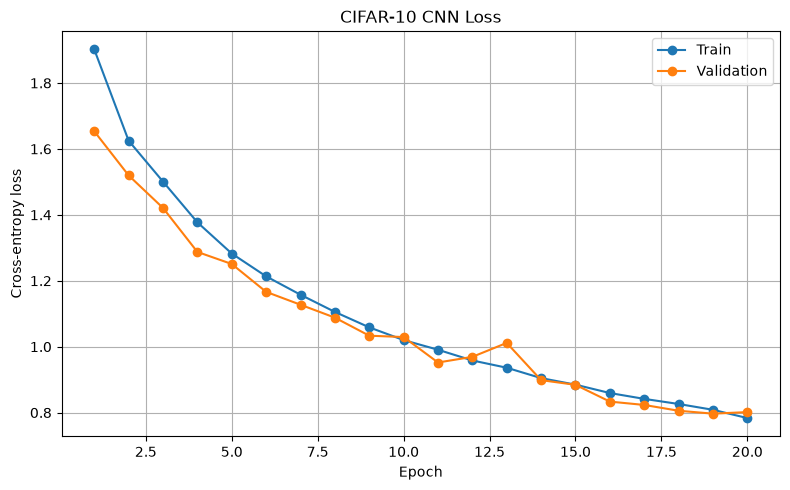

In [15]:
# train / validation loss
figure = plt.figure(figsize=(8, 5))
axis = figure.add_subplot(1, 1, 1)

axis.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)
axis.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation",
)

axis.set_xlabel("Epoch")
axis.set_ylabel("Cross-entropy loss")
axis.set_title("CIFAR-10 CNN Loss")
axis.grid(True)
axis.legend()

figure.tight_layout()

loss_figure_path = (
    figure_dir
    / "cifar10_cnn_loss.png"
)
figure.savefig(
    loss_figure_path,
    dpi=150,
)

plt.show()


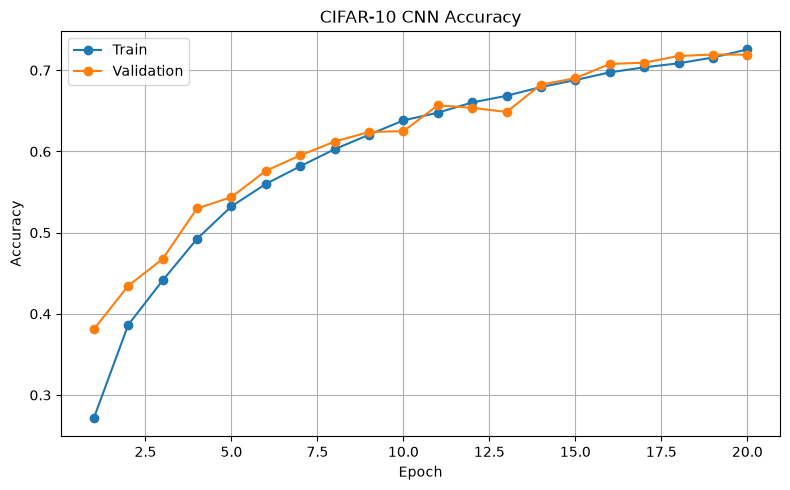

In [16]:
# train / validation accuracy
figure = plt.figure(figsize=(8, 5))
axis = figure.add_subplot(1, 1, 1)

axis.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train",
)
axis.plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation",
)

axis.set_xlabel("Epoch")
axis.set_ylabel("Accuracy")
axis.set_title("CIFAR-10 CNN Accuracy")
axis.grid(True)
axis.legend()

figure.tight_layout()

accuracy_figure_path = (
    figure_dir
    / "cifar10_cnn_accuracy.png"
)
figure.savefig(
    accuracy_figure_path,
    dpi=150,
)

plt.show()


## 13. Confusion Matrix

CIFAR-10は10クラス。

SVD前のbaselineで、どのクラス同士を間違えやすいか記録しておく。

後で層ごとにrankを落としたとき、

> 全体accuracyは少ししか落ちていないのに、特定クラスだけ大きく悪化した

という現象も確認できる。


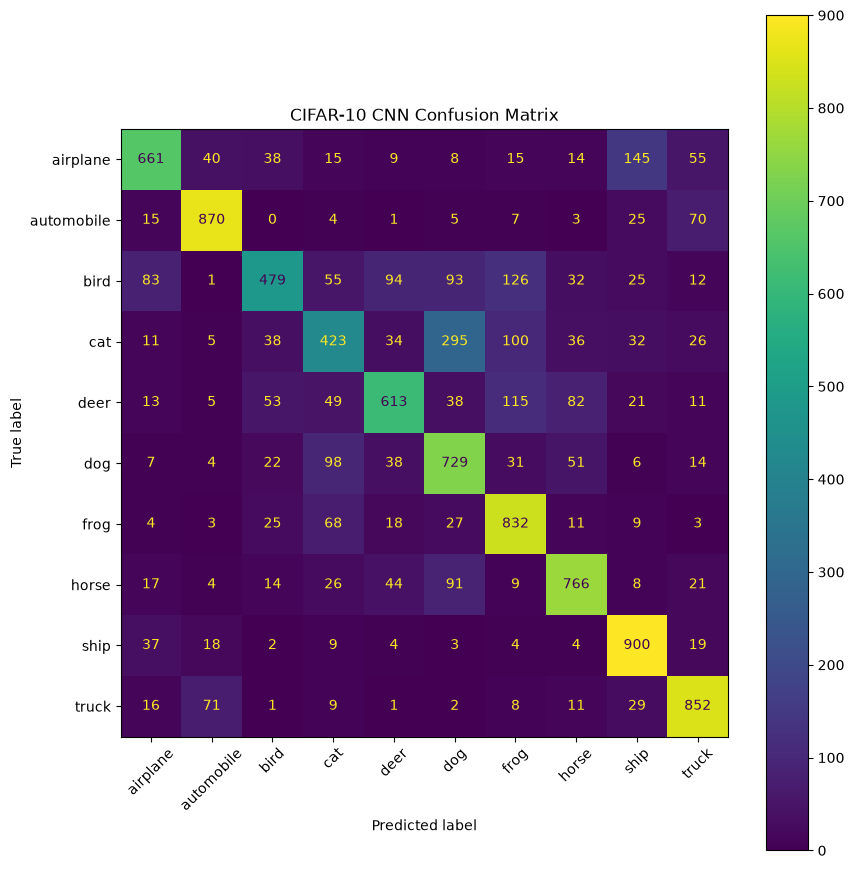

In [17]:
def predict_labels(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """データローダ全体の正解ラベルと予測ラベルを返す。"""

    model.eval()

    true_labels: list[np.ndarray] = []
    predicted_labels: list[np.ndarray] = []

    with torch.inference_mode():
        for inputs, targets in loader:
            inputs = inputs.to(
                device,
                non_blocking=True,
            )

            logits = model(inputs)
            predictions = logits.argmax(dim=1)

            true_labels.append(
                targets.numpy()
            )
            predicted_labels.append(
                predictions.cpu().numpy()
            )

    return (
        np.concatenate(true_labels),
        np.concatenate(predicted_labels),
    )


# torchvision側が持っているクラス名をそのまま使う
CLASS_NAMES = list(test_dataset.classes)

test_targets, test_predictions = predict_labels(
    model=baseline_model,
    loader=test_loader,
    device=device,
)

matrix = confusion_matrix(
    test_targets,
    test_predictions,
)

figure, axis = plt.subplots(
    figsize=(9, 9)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)
display.plot(
    ax=axis,
    xticks_rotation=45,
    values_format="d",
)

axis.set_title(
    "CIFAR-10 CNN Confusion Matrix"
)
figure.tight_layout()

confusion_matrix_path = (
    figure_dir
    / "cifar10_cnn_confusion_matrix.png"
)
figure.savefig(
    confusion_matrix_path,
    dpi=150,
)

plt.show()


## 14. Baseline checkpoint保存

後続のSVD実験では、この重みを共通の出発点にする。

毎回baselineを再学習すると、

```text
rank差による変化
```

と

```text
学習乱数による変化
```

が混ざる。

そのため、**同一checkpointから層ごとのSVD感度を比較する**。


In [18]:
checkpoint_path = (
    checkpoint_dir
    / "cifar10_cnn_baseline.pt"
)

torch.save(
    {
        "model_class": "CIFAR10CNN",
        "model_state_dict": baseline_model.state_dict(),
        "model_parameters": baseline_parameter_count,
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs": BASELINE_EPOCHS,
        "best_epoch": best_epoch,
        "learning_rate": BASELINE_LEARNING_RATE,
        "best_validation_loss": best_validation_loss,
        "test_loss": baseline_test_loss,
        "test_accuracy": baseline_test_accuracy,
        "history": history,
        "class_names": CLASS_NAMES,
        "model_config": MODEL_CONFIG,
        "architecture": {
            "conv1_out_channels": CONV1_OUT_CHANNELS,
            "conv2_out_channels": CONV2_OUT_CHANNELS,
            "conv3_out_channels": CONV3_OUT_CHANNELS,
            "hidden_dim": HIDDEN_DIM,
            "dropout_rate": DROPOUT_RATE,
            "kernel_size": 3,
            "padding": 1,
            "pool": "MaxPool2d(2)",
        },
    },
    checkpoint_path,
)

summary_df = pd.DataFrame(
    [
        {
            "dataset": "CIFAR-10",
            "model": "CIFAR10CNN",
            "seed": SEED,
            "batch_size": BATCH_SIZE,
            "max_epochs": BASELINE_EPOCHS,
            "best_epoch": best_epoch,
            "optimizer": "Adam",
            "learning_rate": BASELINE_LEARNING_RATE,
            "criterion": "CrossEntropyLoss",
            "parameters": baseline_parameter_count,
            "validation_loss": best_validation_loss,
            "test_loss": baseline_test_loss,
            "test_accuracy": baseline_test_accuracy,
        }
    ]
)

summary_path = (
    csv_dir
    / "cifar10_cnn_baseline_summary.csv"
)
summary_df.to_csv(
    summary_path,
    index=False,
)

metadata = {
    "dataset": "CIFAR-10",
    "train_size": TRAIN_SIZE,
    "validation_size": VALIDATION_SIZE,
    "test_size": len(test_dataset),
    "train_transform": repr(train_transform),
    "evaluation_transform": repr(evaluation_transform),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "model": "CIFAR10CNN",
    "model_config": MODEL_CONFIG,
    "parameters": baseline_parameter_count,
    "optimizer": "Adam",
    "learning_rate": BASELINE_LEARNING_RATE,
    "max_epochs": BASELINE_EPOCHS,
    "best_epoch": best_epoch,
    "criterion": "CrossEntropyLoss",
    "device": str(device),
    "python_version": sys.version,
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "validation_loss": best_validation_loss,
    "test_loss": baseline_test_loss,
    "test_accuracy": baseline_test_accuracy,
}

metadata_path = (
    metadata_dir
    / "cifar10_cnn_baseline.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(f"checkpoint: {checkpoint_path.resolve()}")
print(f"summary:    {summary_path.resolve()}")
print(f"metadata:   {metadata_path.resolve()}")


checkpoint: D:\dev\nn-compression-svd-dmrg\models\30_cifar10\01_cnn_cifar10_baseline\cifar10_cnn_baseline.pt
summary:    D:\dev\nn-compression-svd-dmrg\results\30_cifar10\01_cnn_cifar10_baseline\cifar10_cnn_baseline_summary.csv
metadata:   D:\dev\nn-compression-svd-dmrg\results\30_cifar10\01_cnn_cifar10_baseline\cifar10_cnn_baseline.json


## 15. 次へ進む前の確認

以下を自分で説明できれば、このNotebookは完了。

- [ ] CIFAR-10の入力がなぜ3channelなのか
- [ ] Convの `in_channels` と前段の `out_channels` の関係
- [ ] `padding=1, kernel_size=3, stride=1` で縦横が維持される理由
- [ ] Poolingを3回通すと `32 → 16 → 8 → 4` になる理由
- [ ] GAP後のshapeと、Flatten後の特徴数を説明できる
- [ ] 最終Linearの出力数が何を表すか
- [ ] trainだけaugmentationする理由
- [ ] `fc1.weight` と `conv*.weight` のTensor次元の違い
- [ ] baselineのvalidation loss / accuracyを記録した
- [ ] baselineのtest loss / accuracyを記録した
- [ ] checkpointを保存した

## 次Notebook

```text
02_layer_sensitivity.ipynb
```

では、各層をいきなり全部圧縮せず、

```text
conv1
conv2
conv3
fc1
```

を**1層ずつ**低rank化し、

- singular value spectrum
- retained energy
- validation accuracy drop
- parameter reduction

を比較する。

Fashion-MNISTで行った

```text
LinearをSVDしてrankを落とす
```

の単純な繰り返しではなく、  
**CNNのどの層が低rank化に強いか**を調べるところから一段進める。
